# Resume Classification

**Flow:** Data -> Quality -> EDA -> Preprocessing -> Split -> TF-IDF -> ML comparison -> LSTM -> Evaluation -> Error Analysis -> Prediction Demo

In [27]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import html
from collections import Counter
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

import joblib

## 1. Load the provided dataset

In [29]:
df = pd.read_csv("Resume.csv", engine="python", on_bad_lines="skip")

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Shape: (1055, 4)
Columns: ['ID', 'Resume_str', 'Resume_html', 'Category']


## 2. Data quality and class balance

In [30]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())
print("Duplicate resume text:", df["Resume_str"].duplicated().sum())

# Clean label formatting before checking classes
df["Category"] = df["Category"].astype("string").str.strip().str.upper()

print("\nClass distribution:")
class_counts = df["Category"].value_counts(dropna=False)
print(class_counts)

print("\nClass percentages:")
print((class_counts / len(df) * 100).round(2))

print("\nNumber of classes:", df["Category"].nunique(dropna=True))
print("Smallest class:", class_counts.drop(labels=[pd.NA], errors="ignore").min())
print("Largest class:", class_counts.drop(labels=[pd.NA], errors="ignore").max())

Missing values:
ID             0
Resume_str     0
Resume_html    0
Category       0
dtype: int64

Duplicate rows: 46
Duplicate resume text: 47

Class distribution:
Category
DESIGNER                  135
HR                        129
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
FITNESS                   117
HEALTHCARE                115
TEACHER                   102
AGRICULTURE                63
BPO                        22
SALES                      14
Name: count, dtype: Int64

Class percentages:
Category
DESIGNER                   12.8
HR                        12.23
INFORMATION-TECHNOLOGY    11.37
BUSINESS-DEVELOPMENT      11.37
ADVOCATE                  11.18
FITNESS                   11.09
HEALTHCARE                 10.9
TEACHER                    9.67
AGRICULTURE                5.97
BPO                        2.09
SALES                      1.33
Name: count, dtype: Float64

Number of classes: 11
Smallest class: 14
Largest class: 135


## 3. Remove unusable rows and duplicate resumes
Duplicate resumes are removed **before splitting** so the same resume cannot appear in both training and test sets.

In [31]:
df = df.dropna(subset=["Resume_str", "Category"]).copy()
df["Resume_str"] = df["Resume_str"].astype(str)

df = df[df["Resume_str"].str.strip() != ""]

before = len(df)
df = df.drop_duplicates(subset="Resume_str").reset_index(drop=True)

print("Rows removed as duplicate resumes:", before - len(df))
print("Final rows before preprocessing:", len(df))
print("Classes:", df["Category"].nunique())

Rows removed as duplicate resumes: 47
Final rows before preprocessing: 1007
Classes: 11


## 4. Category distribution

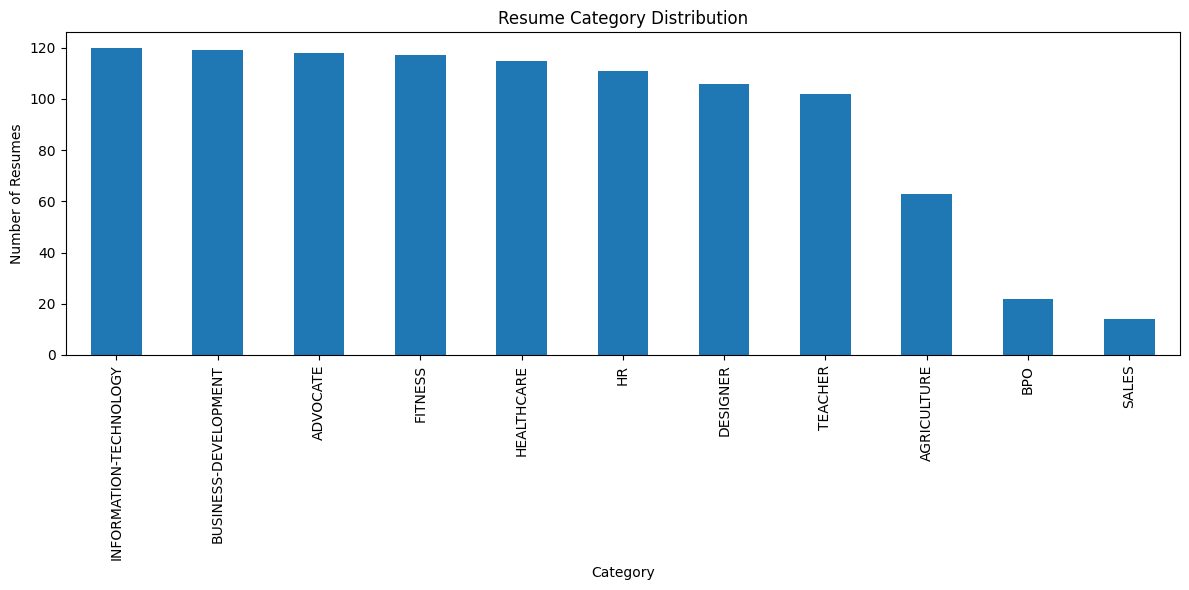

In [32]:
plt.figure(figsize=(12, 6))
df["Category"].value_counts().plot(kind="bar")
plt.title("Resume Category Distribution")
plt.xlabel("Category")
plt.ylabel("Number of Resumes")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## 5. Resume length

count     1007.000000
mean      6360.268123
std       2601.131280
min        985.000000
25%       5199.000000
50%       5913.000000
75%       7365.000000
max      24834.000000
Name: text_length, dtype: float64

Resumes shorter than 100 characters: 0


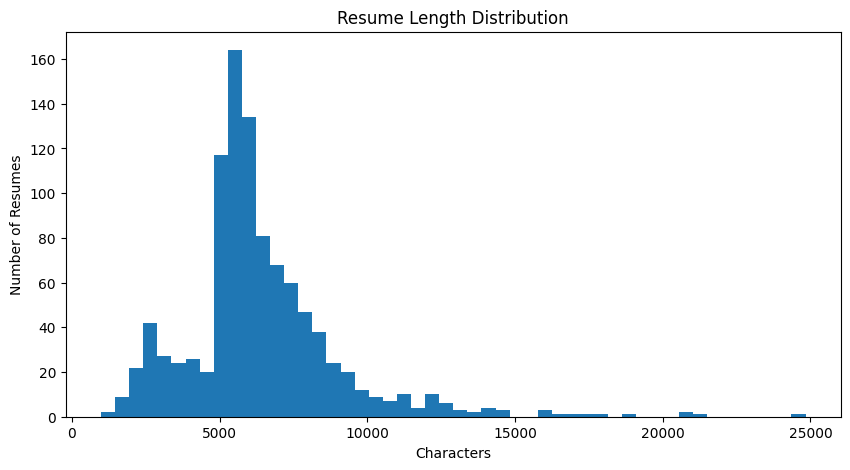

In [33]:
df["text_length"] = df["Resume_str"].str.len()

print(df["text_length"].describe())
print("\nResumes shorter than 100 characters:",
      (df["text_length"] < 100).sum())

plt.figure(figsize=(10, 5))
plt.hist(df["text_length"], bins=50)
plt.title("Resume Length Distribution")
plt.xlabel("Characters")
plt.ylabel("Number of Resumes")
plt.show()

## 6. Most frequent words and WordCloud

[('and', 50371), ('to', 22642), ('of', 17157), ('the', 14815), ('in', 11657), ('for', 11409), ('with', 9006), ('a', 6835), ('state', 6701), ('city', 6161), ('company', 5973), ('management', 4984), ('name', 4742), ('as', 4384), ('on', 4059), ('business', 3474), ('sales', 3367), ('customer', 3349), ('skills', 3280), ('all', 3265)]


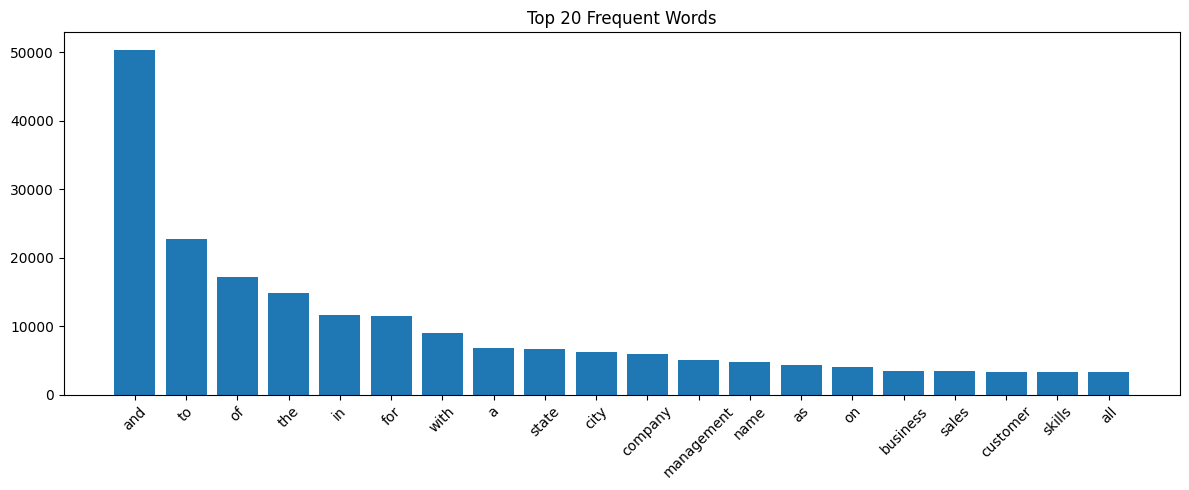

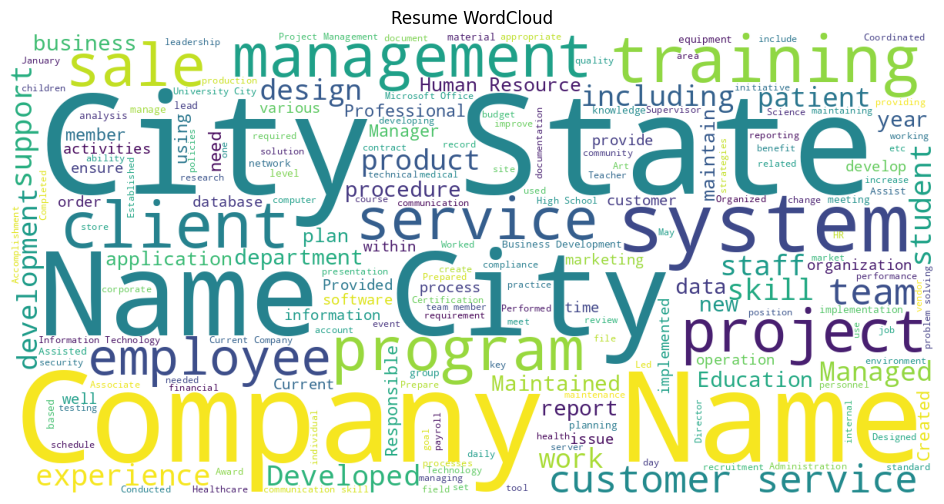

In [34]:
def get_words(text):
    return re.findall(r"\b[a-zA-Z][a-zA-Z+#.\-]*\b", text.lower())

all_text = " ".join(df["Resume_str"].fillna("").astype(str))
word_counts = Counter(get_words(all_text))
common_words = word_counts.most_common(20)

print(common_words)

words = [x[0] for x in common_words]
counts = [x[1] for x in common_words]

plt.figure(figsize=(12, 5))
plt.bar(words, counts)
plt.title("Top 20 Frequent Words")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

wordcloud = WordCloud(width=1200, height=600, background_color="white").generate(all_text)
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Resume WordCloud")
plt.show()

## 7. Bigram analysis

In [35]:
bigram = CountVectorizer(
    ngram_range=(2, 2),
    stop_words="english",
    max_features=20
)

matrix = bigram.fit_transform(df["Resume_str"])
counts = matrix.sum(axis=0).A1
names = bigram.get_feature_names_out()

print(sorted(zip(names, counts), key=lambda x: x[1], reverse=True))

[('city state', np.int64(5785)), ('company city', np.int64(4009)), ('customer service', np.int64(1372)), ('business development', np.int64(631)), ('human resources', np.int64(549)), ('information technology', np.int64(538)), ('current company', np.int64(510)), ('university city', np.int64(509)), ('project management', np.int64(455)), ('microsoft office', np.int64(453)), ('high school', np.int64(411)), ('communication skills', np.int64(338)), ('problem solving', np.int64(337)), ('policies procedures', np.int64(330)), ('bachelor science', np.int64(328)), ('college city', np.int64(302)), ('customer satisfaction', np.int64(293)), ('human resource', np.int64(291)), ('2014 company', np.int64(288)), ('state university', np.int64(262))]


## 8. Text preprocessing

In [36]:
def clean_resume(text):
    text = html.unescape(str(text))
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"\S+@\S+", " ", text)
    text = re.sub(r"[^a-zA-Z0-9+#.\- ]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.lower().strip()

df["clean_text"] = df["Resume_str"].apply(clean_resume)
df = df[df["clean_text"] != ""].reset_index(drop=True)

print("Rows after preprocessing:", len(df))
print("\nBefore:")
print(df["Resume_str"].iloc[0][:300])
print("\nAfter:")
print(df["clean_text"].iloc[0][:300])

Rows after preprocessing: 1007

Before:
         HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Respected builder and leader of customer-focused teams; strives to instill a shared, enthusiastic commit

After:
hr administrator marketing associate hr administrator summary dedicated customer service manager with 15+ years of experience in hospitality and customer service management. respected builder and leader of customer-focused teams strives to instill a shared enthusiastic commitment to customer service


## 9. Train / validation / test split

In [37]:
X = df["clean_text"]
y = df["Category"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print("Training:", len(X_train))
print("Validation:", len(X_val))
print("Testing:", len(X_test))
print("Classes in train/val/test:",
      y_train.nunique(), y_val.nunique(), y_test.nunique())

Training: 704
Validation: 151
Testing: 152
Classes in train/val/test: 11 11 11


## 10. TF-IDF

In [38]:
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_features=15000
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF shape:", X_train_tfidf.shape)

TF-IDF shape: (704, 15000)


## 11. Classical ML comparison

In [39]:
lr = LogisticRegression(max_iter=2000, class_weight="balanced")
lr.fit(X_train_tfidf, y_train)
lr_pred = lr.predict(X_val_tfidf)

svm = LinearSVC(class_weight="balanced")
svm.fit(X_train_tfidf, y_train)
svm_pred = svm.predict(X_val_tfidf)

nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)
nb_pred = nb.predict(X_val_tfidf)

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Linear SVM", "Naive Bayes"],
    "Accuracy": [
        accuracy_score(y_val, lr_pred),
        accuracy_score(y_val, svm_pred),
        accuracy_score(y_val, nb_pred)
    ],
    "Macro F1": [
        f1_score(y_val, lr_pred, average="macro"),
        f1_score(y_val, svm_pred, average="macro"),
        f1_score(y_val, nb_pred, average="macro")
    ]
})

print(results)

                 Model  Accuracy  Macro F1
0  Logistic Regression  0.788079  0.705823
1           Linear SVM  0.807947  0.676308
2          Naive Bayes  0.662252  0.507870


## 12. Deep learning model — LSTM

In [40]:
label_encoder = LabelEncoder()

y_train_enc = label_encoder.fit_transform(y_train)
y_val_enc = label_encoder.transform(y_val)
y_test_enc = label_encoder.transform(y_test)

tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

def make_sequences(texts):
    return pad_sequences(
        tokenizer.texts_to_sequences(texts),
        maxlen=300,
        padding="post",
        truncating="post"
    )

X_train_pad = make_sequences(X_train)
X_val_pad = make_sequences(X_val)
X_test_pad = make_sequences(X_test)

lstm = Sequential([
    Embedding(10000, 64),
    LSTM(64),
    Dropout(0.3),
    Dense(len(label_encoder.classes_), activation="softmax")
])

lstm.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

lstm.fit(
    X_train_pad,
    y_train_enc,
    validation_data=(X_val_pad, y_val_enc),
    epochs=5,
    batch_size=32
)

_, lstm_accuracy = lstm.evaluate(X_test_pad, y_test_enc, verbose=0)
print("LSTM Test Accuracy:", lstm_accuracy)

Epoch 1/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 227ms/step - accuracy: 0.1293 - loss: 2.3780 - val_accuracy: 0.0993 - val_loss: 2.3300
Epoch 2/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 141ms/step - accuracy: 0.1463 - loss: 2.2828 - val_accuracy: 0.1457 - val_loss: 2.2876
Epoch 3/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 136ms/step - accuracy: 0.1832 - loss: 2.2152 - val_accuracy: 0.1589 - val_loss: 2.2276
Epoch 4/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 145ms/step - accuracy: 0.3111 - loss: 2.1164 - val_accuracy: 0.2053 - val_loss: 2.2690
Epoch 5/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 162ms/step - accuracy: 0.3722 - loss: 1.9248 - val_accuracy: 0.2384 - val_loss: 2.1039
LSTM Test Accuracy: 0.21710526943206787


## 13. Final evaluation — best classical model

In [41]:
svm_test_pred = svm.predict(X_test_tfidf)

print("SVM Test Accuracy:",
      accuracy_score(y_test, svm_test_pred))

print("\nClassification Report:")
print(classification_report(y_test, svm_test_pred, zero_division=0))

SVM Test Accuracy: 0.7828947368421053

Classification Report:
                        precision    recall  f1-score   support

              ADVOCATE       0.50      0.28      0.36        18
           AGRICULTURE       0.75      0.33      0.46         9
                   BPO       0.67      0.67      0.67         3
  BUSINESS-DEVELOPMENT       0.75      1.00      0.86        18
              DESIGNER       0.94      0.94      0.94        16
               FITNESS       0.78      0.78      0.78        18
            HEALTHCARE       0.71      0.67      0.69        18
                    HR       0.85      1.00      0.92        17
INFORMATION-TECHNOLOGY       0.77      0.94      0.85        18
                 SALES       1.00      0.50      0.67         2
               TEACHER       0.88      1.00      0.94        15

              accuracy                           0.78       152
             macro avg       0.78      0.74      0.74       152
          weighted avg       0.77      0

## 14. Confusion matrix

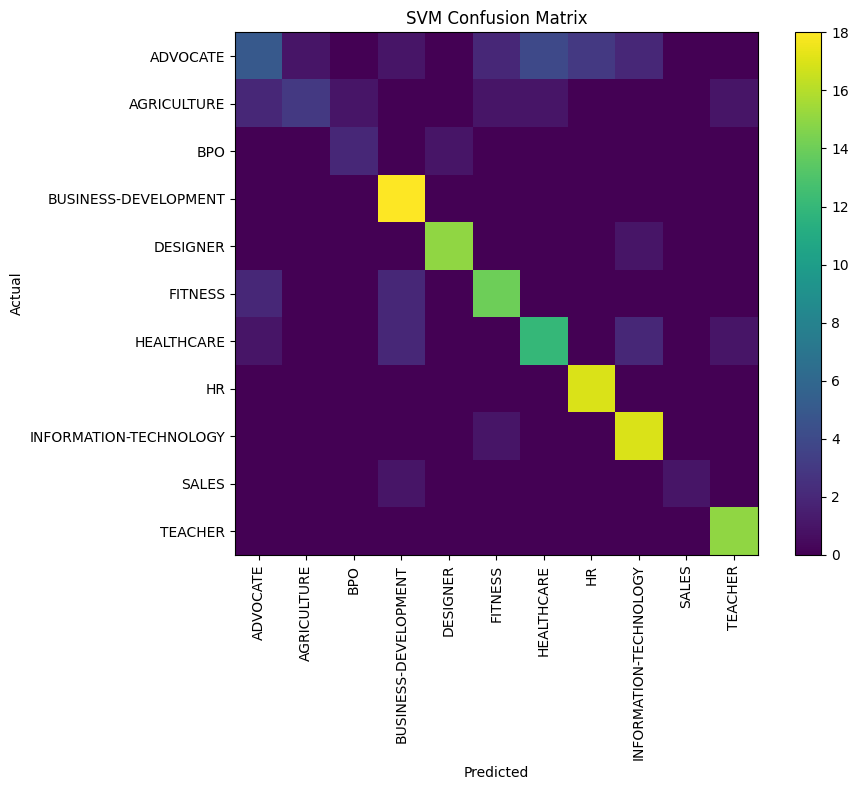

In [42]:
labels = sorted(y_test.unique())
cm = confusion_matrix(y_test, svm_test_pred, labels=labels)

plt.figure(figsize=(10, 8))
plt.imshow(cm)
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()

plt.xticks(range(len(labels)), labels, rotation=90)
plt.yticks(range(len(labels)), labels)

plt.tight_layout()
plt.show()

## 15. Error analysis

In [43]:
errors = pd.DataFrame({
    "Actual": y_test.to_numpy(),
    "Predicted": svm_test_pred,
    "Resume": X_test.to_numpy()
})

errors = errors[errors["Actual"] != errors["Predicted"]]

print("Wrong predictions:", len(errors))
display(errors.head(10))

Wrong predictions: 33


,Actual,Predicted,Resume
0,FITNESS,ADVOCATE,social media agent summary college prepared st...
10,AGRICULTURE,FITNESS,detective summary law enforcement professional...
11,ADVOCATE,INFORMATION-TECHNOLOGY,senior client advocate ii accomplishments earn...
18,ADVOCATE,HR,human resources manager summary to continue my...
19,ADVOCATE,AGRICULTURE,finance director professional summary to find ...
21,ADVOCATE,HEALTHCARE,senior application specialist professional sum...
22,ADVOCATE,INFORMATION-TECHNOLOGY,customer success advocate professional profile...
26,HEALTHCARE,ADVOCATE,licensed healthcare communicator summary to ob...
38,ADVOCATE,HR,advocate summary seeking a part time or prn ge...
45,ADVOCATE,HEALTHCARE,member advocate education and training 2009 un...


## 16. Save the final classifier

In [44]:
import joblib

save_path = "/content/drive/MyDrive/Hackathon/resume_classifier.pkl"

joblib.dump(
    {
        "tfidf": tfidf,
        "model": svm,
        "clean_resume": clean_resume
    },
    save_path
)

print("Saved to:", save_path)

Saved to: /content/drive/MyDrive/Hackathon/resume_classifier.pkl


## 17. Upload a resume and predict

In [ ]:
from IPython.display import display
from google.colab import files

uploaded = files.upload()
file_name = next(iter(uploaded))
print("Uploaded:", file_name)

In [ ]:
# Install required PDF and DOCX parsers if they are not already installed
import sys
try:
    import pypdf
except ImportError:
    !{sys.executable} -m pip install pypdf

try:
    import docx
except ImportError:
    !{sys.executable} -m pip install python-docx

def extract_resume_text(file_name):
    ext = file_name.lower().split(".")[-1]

    if ext == "txt":
        with open(file_name, "r", encoding="utf-8", errors="ignore") as f:
            return f.read()

    if ext == "pdf":
        from pypdf import PdfReader
        reader = PdfReader(file_name)
        return "\n".join(page.extract_text() or "" for page in reader.pages)

    if ext == "docx":
        from docx import Document
        doc = Document(file_name)
        return "\n".join(p.text for p in doc.paragraphs)

    raise ValueError("Supported formats: PDF, DOCX, TXT")

resume_text = extract_resume_text(file_name)

features = tfidf.transform([clean_resume(resume_text)])
prediction = svm.predict(features)[0]

print("Predicted Resume Category:", prediction)